In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PNG_FILE = PROJECT_ROOT / "10.png"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = RESULTS_DIR / "unet_star_detector.pth"


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

IMAGE_SIZE = 256

TRAIN_SAMPLES = 1500
VAL_SAMPLES = 200

BATCH_SIZE = 16
EPOCHS = 8

LEARNING_RATE = 1e-3

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


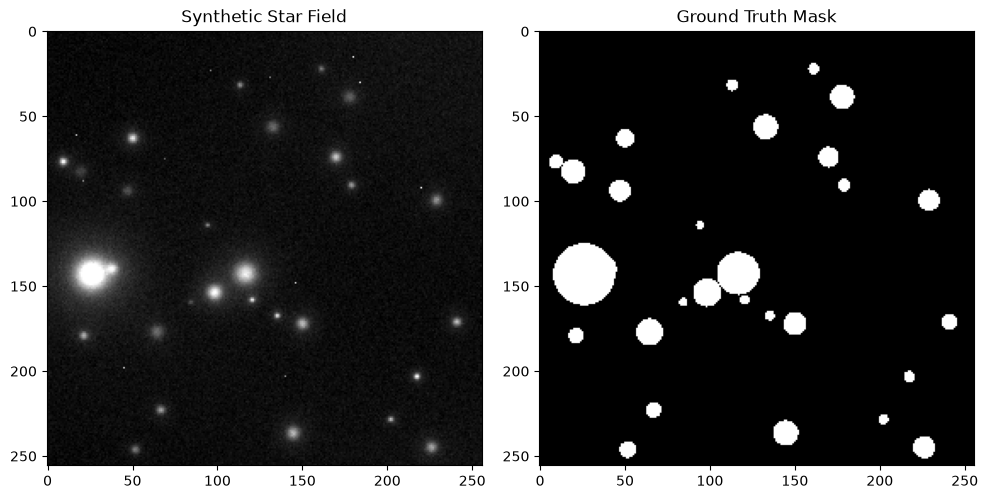

In [3]:
class SyntheticStarDataset(Dataset):

    def __init__(
        self,
        n_samples,
        image_size=256,
        seed=42,
    ):
        self.n_samples = n_samples
        self.image_size = image_size
        self.seed = seed


    def __len__(self):
        return self.n_samples


    def __getitem__(self, index):

        rng = np.random.default_rng(
            self.seed + index
        )

        size = self.image_size

        yy, xx = np.mgrid[0:size, 0:size]


        # ----------------------------------------------------
        # Create a non-uniform sky background
        # ----------------------------------------------------

        base_level = rng.uniform(0.03, 0.15)

        gradient_x = rng.uniform(-0.08, 0.08)
        gradient_y = rng.uniform(-0.08, 0.08)

    background = (base_level + gradient_x * xx / size + gradient_y * yy / size)

    # Add low-frequency background structure

    cloud_amp = rng.uniform(0.0, 0.08)

    cloud = cloud_amp * (np.sin(xx / rng.uniform(30, 100) + rng.uniform(0, 2 * np.pi)) * np.sin(yy / rng.uniform(30, 100) + rng.uniform(0, 2 * np.pi)))

    image = background + cloud

    # ----------------------------------------------------
    # Create stars and ground-truth mask
    # ----------------------------------------------------

    mask = np.zeros((size, size), dtype=np.float32)

    n_stars = rng.integers(15, 90)

    for _ in range(n_stars):

        x0 = rng.uniform(5, size - 5)
        y0 = rng.uniform(5, size - 5)

        # Generate stars with a wider range of apparent sizes

        if rng.random() < 0.15:

            # Large bright stars
            sigma = rng.uniform(3.0, 7.0)
            amplitude = rng.uniform(0.8, 2.0)

        else:

            # Normal stars
            sigma = rng.uniform(0.7, 2.8)
            amplitude = rng.uniform(0.2, 1.0)

        # Main stellar core

        core = amplitude * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma**2))

        # Add a broader halo for bright stars

        halo = 0.15 * amplitude * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * (sigma * 3.0) ** 2))

        star = core + halo

        image += star

        # Ground-truth region around the star

        radius = max(2.0, sigma * 3.0)

        star_mask = ((xx - x0) ** 2 + (yy - y0) ** 2 <= radius**2)

        mask[star_mask] = 1.0

    # ----------------------------------------------------
    # Add sensor noise
    # ----------------------------------------------------

    noise_sigma = rng.uniform(0.01, 0.05)

    image += rng.normal(0, noise_sigma, image.shape)

    # Add a few isolated bright noise pixels

    n_hot_pixels = rng.integers(0, 20)

    for _ in range(n_hot_pixels):

        x = rng.integers(0, size)
        y = rng.integers(0, size)

        image[y, x] += rng.uniform(0.2, 1.0)

    # ----------------------------------------------------
    # Normalize
    # ----------------------------------------------------

    low, high = np.percentile(image, [1, 99.8])

    image = ((image - low) / (high - low + 1e-8))

    image = np.clip(image, 0, 1).astype(np.float32)

    image = torch.from_numpy(image[None, :, :])

    mask = torch.from_numpy(mask[None, :, :])

    return image, mask


train_dataset = SyntheticStarDataset(
    TRAIN_SAMPLES,
    IMAGE_SIZE,
    seed=1000,
)

val_dataset = SyntheticStarDataset(
    VAL_SAMPLES,
    IMAGE_SIZE,
    seed=100000,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# Show one example

example_image, example_mask = train_dataset[0]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

axes[0].imshow(
    example_image[0],
    cmap="gray",
)
axes[0].set_title("Synthetic Star Field")

axes[1].imshow(
    example_mask[0],
    cmap="gray",
)
axes[1].set_title("Ground Truth Mask")

plt.tight_layout()
plt.show()

In [4]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1,16,)
        self.enc2 = DoubleConv(16,32,)
        self.enc3 = DoubleConv(32,64,)
        self.enc4 = DoubleConv(64,128,)

        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(128,256,)

        # Decoder
        self.up4 = nn.ConvTranspose2d(256,128, kernel_size=2, stride=2,)
        self.dec4 = DoubleConv(256,128,)
        self.up3 = nn.ConvTranspose2d(128,64, kernel_size=2, stride=2,)
        self.dec3 = DoubleConv(128,64,)
        self.up2 = nn.ConvTranspose2d(64,32, kernel_size=2, stride=2,)
        self.dec2 = DoubleConv(64,32,)
        self.up1 = nn.ConvTranspose2d(32,16, kernel_size=2, stride=2,)
        self.dec1 = DoubleConv(32,16,)
        self.output = nn.Conv2d(16,1, kernel_size=1,)

    
    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1,)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1,)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1,)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1,)
        d1 = self.dec1(d1)

        return self.output(d1)


model = UNet().to(DEVICE)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    ),
)

Parameters: 1943761


In [5]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [8.0],
        device=DEVICE,
    )
)


def dice_loss(logits, targets, smooth=1.0,):

    probabilities = torch.sigmoid(logits)

    intersection = (probabilities * targets).sum(dim=(1, 2, 3))

    denominator = (probabilities.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)))

    dice = (2 * intersection + smooth) / (denominator + smooth)

    return 1 - dice.mean()


def combined_loss(
    logits,
    targets,
):

    return (bce_loss(logits, targets,) + dice_loss(logits, targets,))


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)


train_history = []
val_history = []
val_iou_history = []

for epoch in range(EPOCHS):


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0


    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = combined_loss(logits, masks,)

        loss.backward()

        optimizer.step()

        train_loss += (loss.item() * images.size(0))

    train_loss /= len(train_loader.dataset)


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0

    intersection_total = 0
    union_total = 0


    with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)

        loss = combined_loss(logits, masks)

        val_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(logits) > 0.5)

        targets = masks > 0.5

        intersection_total += (predictions & targets).sum().item()

        union_total += (predictions | targets).sum().item()


val_loss /= len(val_loader.dataset)

iou = (intersection_total / max(union_total, 1))


train_history.append(train_loss)
val_history.append(val_loss)
val_iou_history.append(iou)

print(f"Epoch {epoch + 1:02d}/{EPOCHS} | " f"Train Loss: {train_loss:.4f} | " f"Val Loss: {val_loss:.4f} | " f"Val IoU: {iou:.4f}")


torch.save(model.state_dict(), MODEL_FILE)

print("\nModel saved:", MODEL_FILE)

Epoch 01/8 | Train Loss: 1.0807 | Val Loss: 0.8539 | Val IoU: 0.7410
Epoch 02/8 | Train Loss: 0.6512 | Val Loss: 0.5646 | Val IoU: 0.9310
Epoch 03/8 | Train Loss: 0.4091 | Val Loss: 0.3380 | Val IoU: 0.9113
Epoch 04/8 | Train Loss: 0.2672 | Val Loss: 0.2229 | Val IoU: 0.9437
Epoch 05/8 | Train Loss: 0.1854 | Val Loss: 0.1499 | Val IoU: 0.9424
Epoch 06/8 | Train Loss: 0.1606 | Val Loss: 0.1356 | Val IoU: 0.9220
Epoch 07/8 | Train Loss: 0.1225 | Val Loss: 0.1395 | Val IoU: 0.9408
Epoch 08/8 | Train Loss: 0.1116 | Val Loss: 0.1253 | Val IoU: 0.9052

Model saved: results\unet_star_detector.pth


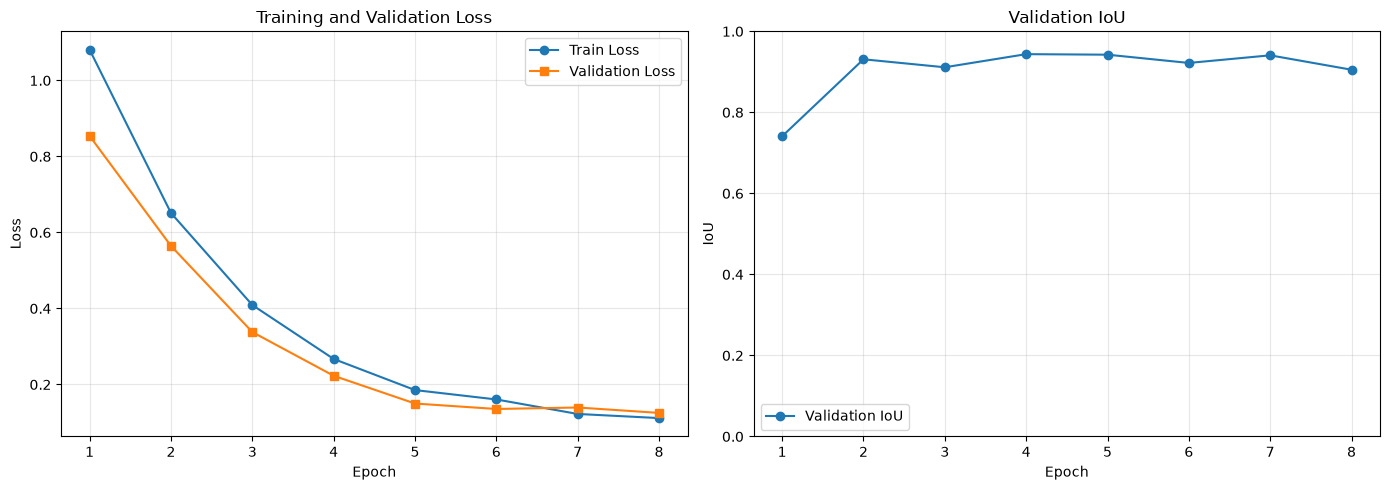

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Check that training history exists
if "train_history" not in globals():
    raise ValueError("train_history not found.")
if "val_history" not in globals():
    raise ValueError("val_history not found.")
if "val_iou_history" not in globals():
    raise ValueError("val_iou_history not found. Please append IoU during training.")

epochs = np.arange(1, len(train_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# Plot loss curves
# ------------------------------------------------------------
axes[0].plot(epochs, train_history, marker="o", label="Train Loss")
axes[0].plot(epochs, val_history, marker="s", label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(epochs)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ------------------------------------------------------------
# Plot validation IoU curve
# ------------------------------------------------------------
axes[1].plot(epochs, val_iou_history, marker="o", label="Validation IoU")
axes[1].set_title("Validation IoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "training_curves.png", dpi=200, bbox_inches="tight")

Real image shape: (3132, 5543)


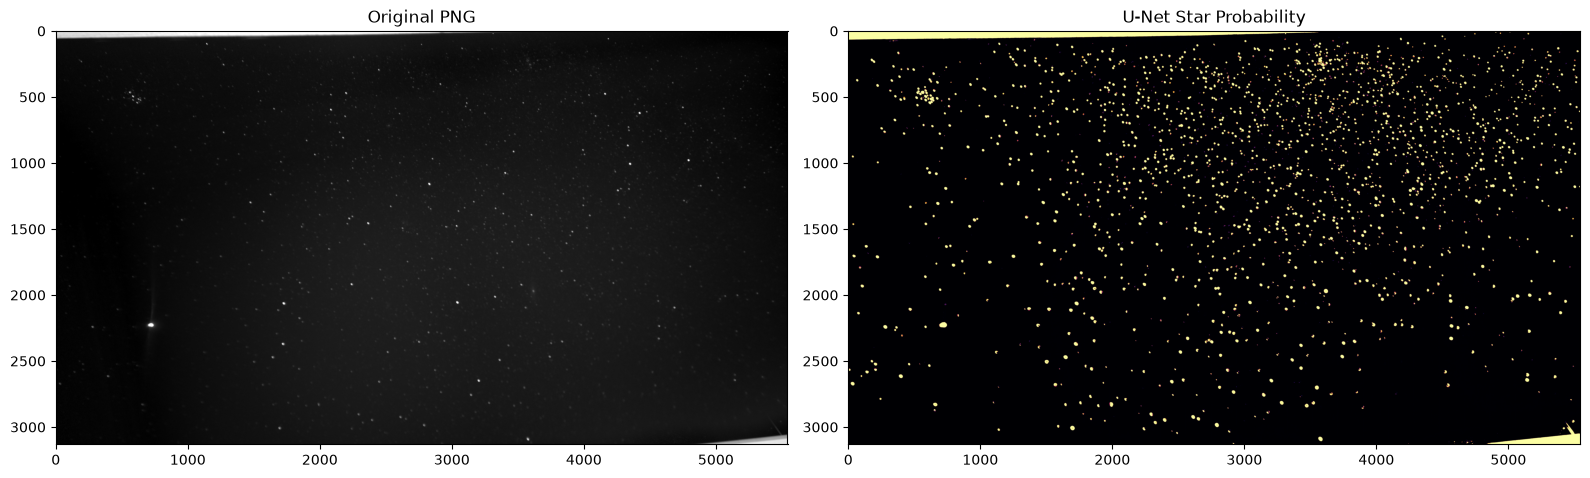

In [7]:
# ------------------------------------------------------------
# Load and normalize the real PNG
# ------------------------------------------------------------

rgb = np.asarray(Image.open(PNG_FILE).convert("RGB"), dtype=np.float32)

gray = (0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2])

low, high = np.percentile(gray, [1, 99.8])

real_image = ((gray - low) / (high - low + 1e-8))

real_image = np.clip(real_image, 0, 1).astype(np.float32)

height, width = real_image.shape

print("Real image shape:", real_image.shape)

# ------------------------------------------------------------
# Patch-based neural-network inference
# ------------------------------------------------------------

PATCH_SIZE = 256
STRIDE = 192

probability_sum = np.zeros((height, width), dtype=np.float32)

probability_count = np.zeros((height, width), dtype=np.float32)

model.eval()

with torch.no_grad():

    for y in range(0, height, STRIDE):

        for x in range(0, width, STRIDE):

            y2 = min(y + PATCH_SIZE, height)

            x2 = min(x + PATCH_SIZE, width)

            y1 = max(0, y2 - PATCH_SIZE)

            x1 = max(0, x2 - PATCH_SIZE)

            patch = real_image[y1:y2, x1:x2]

            if patch.shape[0] != PATCH_SIZE or patch.shape[1] != PATCH_SIZE:
                continue

            tensor = torch.from_numpy(patch[None, None, :, :]).to(DEVICE)

            logits = model(tensor)

            probability = torch.sigmoid(logits).cpu().numpy()[0, 0]

            probability_sum[y1:y2, x1:x2] += probability

            probability_count[y1:y2, x1:x2] += 1


probability_map = (probability_sum / np.maximum(probability_count, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(real_image, cmap="gray")

axes[0].set_title("Original PNG")

axes[1].imshow(probability_map, cmap="inferno", vmin=0, vmax=1)

axes[1].set_title("U-Net Star Probability")

plt.tight_layout()
plt.show()

In [8]:
# Detection parameters

PROBABILITY_THRESHOLD = 0.65

MIN_AREA = 3
MAX_AREA = None

# Convert probability map to binary segmentation

binary_mask = (probability_map >= PROBABILITY_THRESHOLD)

# Remove isolated noise

binary_mask = ndimage.binary_opening(binary_mask, structure=np.ones((2, 2), dtype=bool))

# Connected-component analysis

labels, n_labels = ndimage.label(binary_mask)

objects = []

for label_id in range(1, n_labels + 1):

    region = labels == label_id

    area = region.sum()

    if area < MIN_AREA:
        continue

    if MAX_AREA is not None and area > MAX_AREA:
        continue

    y_pixels, x_pixels = np.where(region)

    probabilities = probability_map[region]

    objects.append({"label": label_id, "x": x_pixels.mean(), "y": y_pixels.mean(), "area": area, "mean_probability": probabilities.mean(), "max_probability": probabilities.max()})


print("Raw connected components:", n_labels)
print("Accepted objects:", len(objects))

Raw connected components: 2004
Accepted objects: 2004


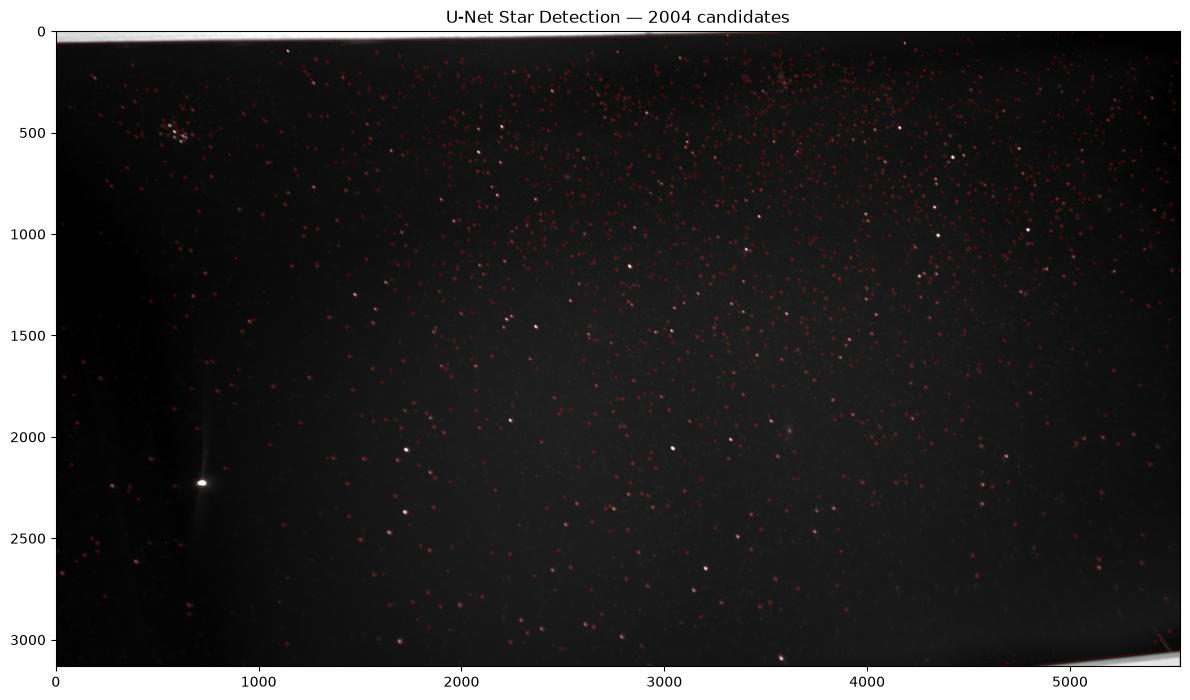

Objects: 2004
Catalog: results\unet_star_catalog.csv
Image: results\unet_star_detection.png


In [9]:
import csv

# ------------------------------------------------------------
# Build the final accepted-object mask
# ------------------------------------------------------------

final_mask = np.zeros_like(binary_mask, dtype=bool)

for obj in objects:

    final_mask[labels == obj["label"]] = True

# ------------------------------------------------------------
# Find segmentation boundaries
# ------------------------------------------------------------

eroded = ndimage.binary_erosion(final_mask)

boundaries = (final_mask & ~eroded)

# ------------------------------------------------------------
# Display segmentation
# ------------------------------------------------------------

plt.figure(figsize=(12, 12))

plt.imshow(real_image, cmap="gray")

boundary_overlay = np.ma.masked_where(~boundaries, boundaries)

plt.imshow(boundary_overlay, cmap="autumn", alpha=0.9)

plt.title(f"U-Net Star Detection — {len(objects)} candidates")

plt.tight_layout()

OUTPUT_IMAGE = (RESULTS_DIR / "unet_star_detection.png")

plt.savefig(OUTPUT_IMAGE, dpi=200)

plt.show()

# ------------------------------------------------------------
# Save detected-object catalog
# ------------------------------------------------------------

CATALOG_FILE = (RESULTS_DIR / "unet_star_catalog.csv")

with open(CATALOG_FILE, "w", newline="", encoding="utf-8") as f:

    writer = csv.DictWriter(f, fieldnames=["label", "x", "y", "area", "mean_probability", "max_probability"])

    writer.writeheader()

    writer.writerows(objects)


print("Objects:", len(objects))
print("Catalog:", CATALOG_FILE)
print("Image:", OUTPUT_IMAGE)